In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve, auc
from sklearn.preprocessing import MinMaxScaler
import gc

import tensorflow as tf
import optuna

import warnings
warnings.filterwarnings('ignore')

I0000 00:00:1781083915.640535   19393 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781083915.673355   19393 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781083916.768202   19393 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
tf.config.list_physical_devices('GPU')

W0000 00:00:1781083917.359894   19393 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
data = yf.download(['RUB=X', 'BZ=F', 'NG=F'], start='2000-01-01', multi_level_index=False, auto_adjust=False)['Close'].reset_index().dropna()
data.columns = ['Date', 'oil', 'gas', 'usd_rub']

data = data[data['usd_rub'] > 10]

data

[*********************100%***********************]  3 of 3 completed


,Date,oil,gas,usd_rub
1762,2007-07-30,75.739998,6.499,25.535999
1763,2007-07-31,77.050003,6.191,25.573999
1764,2007-08-01,75.349998,6.352,25.580000
1765,2007-08-02,75.760002,6.106,25.558001
1766,2007-08-03,74.750000,6.090,25.488001
...,...,...,...,...
6674,2026-06-03,97.809998,3.214,73.196777
6675,2026-06-04,95.029999,3.336,73.747688
6676,2026-06-05,93.089996,3.229,73.397400
6677,2026-06-08,94.250000,3.147,73.682243


<Axes: xlabel='Date'>

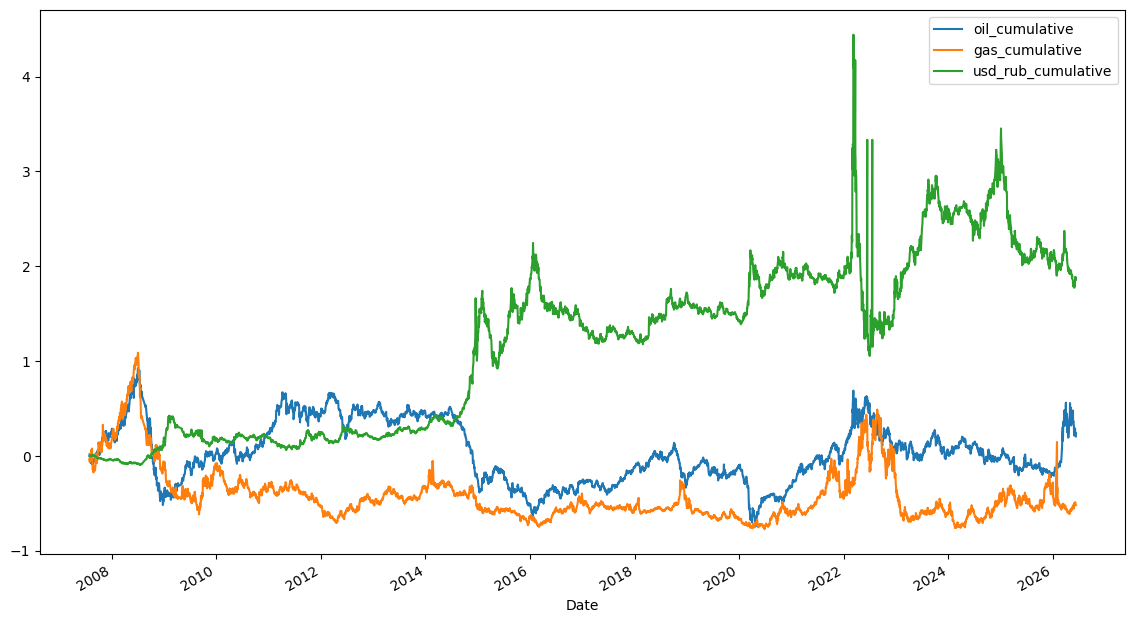

In [4]:
data['oil_cumulative'] = (1 + data['oil'].pct_change()).cumprod() - 1
data['gas_cumulative'] = (1 + data['gas'].pct_change()).cumprod() - 1
data['usd_rub_cumulative'] = (1 + data['usd_rub'].pct_change()).cumprod() - 1

data.set_index('Date')[['oil_cumulative', 'gas_cumulative', 'usd_rub_cumulative']].plot(figsize=[14, 8])

In [5]:
del data['oil_cumulative'], data['gas_cumulative'], data['usd_rub_cumulative']

# Таргет

In [6]:
data['target'] = np.where(data['usd_rub'].shift(-1) > data['usd_rub'], 1, 0)
data

,Date,oil,gas,usd_rub,target
1762,2007-07-30,75.739998,6.499,25.535999,1
1763,2007-07-31,77.050003,6.191,25.573999,1
1764,2007-08-01,75.349998,6.352,25.580000,0
1765,2007-08-02,75.760002,6.106,25.558001,0
1766,2007-08-03,74.750000,6.090,25.488001,0
...,...,...,...,...,...
6674,2026-06-03,97.809998,3.214,73.196777,1
6675,2026-06-04,95.029999,3.336,73.747688,0
6676,2026-06-05,93.089996,3.229,73.397400,1
6677,2026-06-08,94.250000,3.147,73.682243,0


In [7]:
data['target'].value_counts()

target
0    2367
1    2293
Name: count, dtype: int64

# Признаки

In [8]:
data['volatility_usd_rub'] = data['usd_rub'].pct_change(1).rolling(21).std()
data['volatility_oil'] = data['oil'].pct_change(1).rolling(21).std()
data['volatility_gas'] = data['gas'].pct_change(1).rolling(21).std()

data['skew_usd_rub'] = data['usd_rub'].pct_change(1).rolling(21).skew()
data['skew_oil'] = data['oil'].pct_change(1).rolling(21).skew()
data['skew_gas'] = data['gas'].pct_change(1).rolling(21).skew()

data['kurt_usd_rub'] = data['usd_rub'].pct_change(1).rolling(21).kurt()
data['kurt_oil'] = data['oil'].pct_change(1).rolling(21).kurt()
data['kurt_gas'] = data['gas'].pct_change(1).rolling(21).kurt()

data = data.dropna()

data

,Date,oil,gas,usd_rub,target,volatility_usd_rub,volatility_oil,volatility_gas,skew_usd_rub,skew_oil,skew_gas,kurt_usd_rub,kurt_oil,kurt_gas
1783,2007-08-28,70.550003,5.593,25.746000,0,0.002465,0.016206,0.041539,-0.309431,-1.034168,-1.504266,0.835398,1.391035,4.185768
1784,2007-08-29,72.129997,5.430,25.632000,1,0.002664,0.016564,0.040820,-0.224580,-0.917647,-1.608936,0.193224,1.273748,4.843040
1785,2007-08-30,71.900002,5.635,25.638000,1,0.002664,0.015980,0.041349,-0.224549,-1.114946,-1.554259,0.193220,2.156526,4.582805
1786,2007-08-31,72.690002,5.468,25.650999,1,0.002656,0.016156,0.041023,-0.305049,-1.109360,-1.607684,0.269836,2.026297,4.902956
1788,2007-09-04,73.919998,5.629,25.660999,0,0.002570,0.016426,0.041684,-0.448216,-1.245703,-1.624354,0.785140,2.240732,4.691361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6674,2026-06-03,97.809998,3.214,73.196777,1,0.009146,0.032528,0.031134,-0.410806,-0.556027,0.652512,0.224862,-0.493875,0.282905
6675,2026-06-04,95.029999,3.336,73.747688,0,0.009335,0.032037,0.030895,-0.465756,-0.594989,0.463707,0.053140,-0.319876,0.075357
6676,2026-06-05,93.089996,3.229,73.397400,1,0.009212,0.027746,0.031530,-0.322084,-0.292363,0.417056,0.099555,-0.817823,-0.031697
6677,2026-06-08,94.250000,3.147,73.682243,0,0.009058,0.027892,0.032344,-0.521906,-0.414008,0.516425,0.446420,-0.796170,-0.167572


# Разделение выборки

In [9]:
train = data[data['Date'] < '2017-01-01']
validation = data[(data['Date'] >= '2017-01-01') & (data['Date'] <= '2021-01-01')]
test = data[data['Date'] > '2021-01-01']

train.shape, validation.shape, test.shape

((2270, 14), (1004, 14), (1365, 14))

In [10]:
x_train = train.drop(columns=['Date', 'target']).to_numpy()
x_val = validation.drop(columns=['Date', 'target']).to_numpy()
x_test = test.drop(columns=['Date', 'target']).to_numpy()

y_train = train['target'].to_numpy()
y_val = validation['target'].to_numpy()
y_test = test['target'].to_numpy()

x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((2270, 12), (2270,), (1004, 12), (1004,), (1365, 12), (1365,))

# Глобальные константы

In [11]:
EPOCHS = 100
BATCH_SIZE = 256

# Функция LSTM

**Функция создания и обучения LSTM с выведенными гиперпараметрами, как аргементами, для легкой валидации и настройки**

In [12]:
def lstm_model(
    x_train,
    y_train,
    x_val=None,
    y_val=None,
    n_units=64,
    num_layers=2,
    learning_rate=3e-4,
    batch_size=64,
    dropout=0.2,
    epochs=100,
    patience=3,
    loss='binary_crossentropy',
    verbose=1
):

    seq_len = x_train.shape[1]
    input_size = x_train.shape[2]

    inputs = tf.keras.Input(shape=(seq_len, input_size))

    x = inputs

    # LSTM layers
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)

        lstm_layer = tf.keras.layers.LSTM(
            units=n_units,
            dropout=dropout,
            return_sequences=return_seq,
            return_state=False
        )

        x = lstm_layer(x)

    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss=loss,
        metrics=['accuracy']
    )

    has_validation = (x_val is not None and y_val is not None)
    
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss' if has_validation else 'loss',
            patience=patience,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val) if has_validation else None,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    return model, history

# Функция создания последовательности

**Генерация последовательности, для временных рядов это лаги**

In [13]:
def create_sequences(data, targets, time_steps):
    x_seq, y_seq = [], []
    for i in range(len(data) - time_steps + 1):
        x_seq.append(data[i:i + time_steps])
        y_seq.append(targets[i + time_steps - 1])  # target для последнего временного шага
    return np.array(x_seq), np.array(y_seq)

# Базовый scaler для LSTM - MinMax

**MinMax лучше всего подходит для рекуррентных нейронных сетей, это уже доказано и показано множество раз, не имеет смысла подбирать другой препроцессор**

In [14]:
scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(np.concatenate((x_train, x_val)))
x_test_scaled = scaler.transform(x_test)

x_train_seq, y_train_seq = create_sequences(x_train_scaled, np.concatenate((y_train, y_val)), time_steps=1)
x_test_seq, y_test_seq = create_sequences(x_test_scaled, y_test, time_steps=1)

x_train_seq.shape, y_train_seq.shape, x_test_seq.shape, y_test_seq.shape

((3274, 1, 12), (3274,), (1365, 1, 12), (1365,))

In [15]:
model, history = lstm_model(
    x_train=x_train_seq,
    y_train=y_train_seq,
    x_val=None,
    y_val=None,
    n_units=64,
    num_layers=2,
    learning_rate=3e-4,
    batch_size=BATCH_SIZE,
    dropout=0.2,
    epochs=EPOCHS,
    patience=5,
    loss='binary_crossentropy',
    verbose=1
)

W0000 00:00:1781083928.029744   19393 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1781083928.203118   19393 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:02:00.0, compute capability: 12.0a


Epoch 1/100


I0000 00:00:1781083930.192786   19526 cuda_dnn.cc:461] Loaded cuDNN version 92000


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4817 - loss: 0.6932
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5003 - loss: 0.6932
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5049 - loss: 0.6931
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5064 - loss: 0.6931
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5058 - loss: 0.6930
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5055 - loss: 0.6930
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5064 - loss: 0.6930
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5067 - loss: 0.6930
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5064 - loss: 0.6929
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5070 - loss: 0.6930
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5076 - loss: 0.6928
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5064

In [16]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 12)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 1, 64)          │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,405 (618.77 KB)

 Trainable params: 52,801 (206.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 105,604 (412.52 KB)

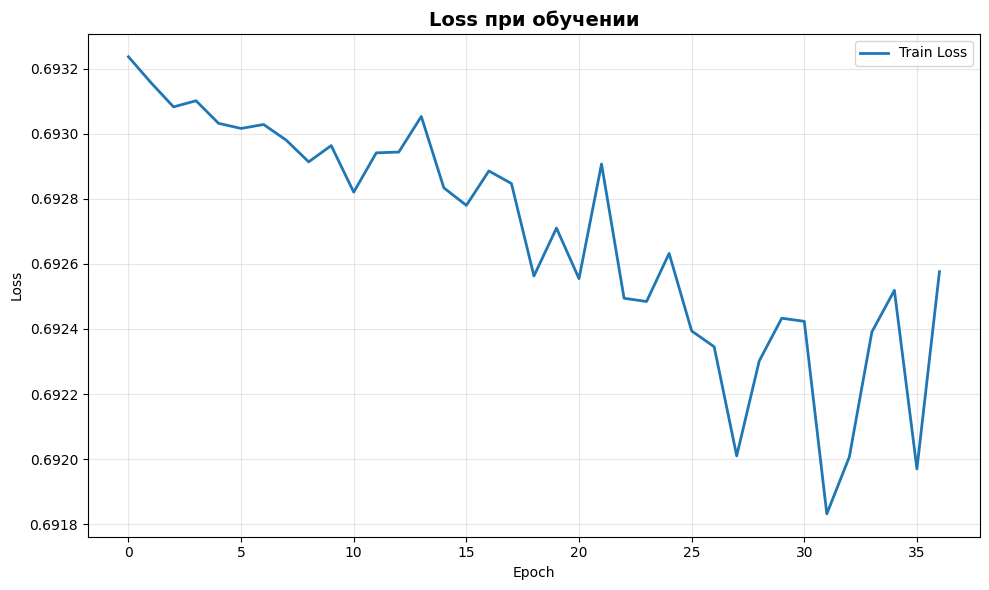

In [17]:
# ================================================================
# Визуализация процесса обучения
# ================================================================

plt.figure(figsize=(10, 6))

# График потерь (Loss)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.title('Loss при обучении', fontweight='bold', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# ================================================================
# Прогноз на тестовой выборке
# ================================================================

y_pred = model.predict(x_test_seq, verbose=1, batch_size=BATCH_SIZE)

y_pred_classes = (y_pred > 0.5).astype("int32")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [19]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print(classification_report(y_test_seq, y_pred_classes))

              precision    recall  f1-score   support

           0       0.50      0.85      0.63       705
           1       0.38      0.10      0.16       660

    accuracy                           0.49      1365
   macro avg       0.44      0.48      0.39      1365
weighted avg       0.45      0.49      0.40      1365



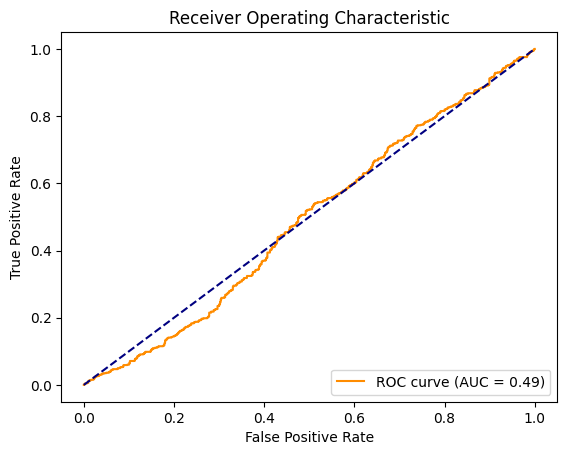

In [20]:
# ================================================================
# ROC-AUC
# ================================================================

# 1. FPR, TPR, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Chance level
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Валидация LSTM (подбор гиперпараметров), tuning

**Создаем пространство гиперпараметров и выбираем наилучшую конфигурацию с помощью ччисленной оптимизации Optuna**

In [21]:
scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)

x_train_scaled.shape, y_train.shape, x_val_scaled.shape, y_val.shape

((2270, 12), (2270,), (1004, 12), (1004,))

In [22]:
def objective(trial):

    n_units = trial.suggest_int('n_units', 64, 512, step=64)
    num_lstm_layers = trial.suggest_int('num_lstm_layers', 1, 4, step=1)
    dropout = trial.suggest_float('dropout', 0, 0.5, step=0.1)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    time_steps = trial.suggest_categorical('time_steps', [1, 5, 21])

    x_train_seq, y_train_seq = create_sequences(x_train_scaled, y_train, time_steps)
    x_val_seq, y_val_seq = create_sequences(x_val_scaled, y_val, time_steps)

    model, history = lstm_model(
        x_train=x_train_seq,
        y_train=y_train_seq,
        x_val=x_val_seq,
        y_val=y_val_seq,
        n_units=n_units,
        num_layers=num_lstm_layers,
        learning_rate=learning_rate,
        batch_size=BATCH_SIZE,
        dropout=dropout,
        epochs=EPOCHS,
        patience=5,
        loss='binary_crossentropy',
        verbose=0
    )

    y_pred = model.predict(x_val_seq, batch_size=BATCH_SIZE, verbose=0)

    y_pred_classes = (y_pred > 0.5).astype("int32")

    score = f1_score(y_val_seq, y_pred_classes)

    del model, history, y_pred, x_train_seq, y_train_seq, x_val_seq, y_val_seq
    
    gc.collect()
    tf.keras.backend.clear_session()

    return score

In [23]:
sampler = optuna.samplers.TPESampler(
    n_startup_trials=5,
    multivariate=True,
    group=True,
    constant_liar=True
)

study = optuna.create_study(direction='maximize', sampler=sampler)

[I 2026-06-10 14:32:22,704] A new study created in memory with name: no-name-8db2d5a5-33ec-4fc1-95a7-3a92864a4c47


In [24]:
study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True,
    gc_after_trial=True,
    n_jobs=1
)

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-10 14:32:29,703] Trial 0 finished with value: 0.2696969696969697 and parameters: {'n_units': 448, 'num_lstm_layers': 1, 'dropout': 0.4, 'learning_rate': 0.0008752137855967996, 'time_steps': 1}. Best is trial 0 with value: 0.2696969696969697.
[I 2026-06-10 14:32:33,177] Trial 1 finished with value: 0.40846824408468246 and parameters: {'n_units': 256, 'num_lstm_layers': 3, 'dropout': 0.0, 'learning_rate': 0.0001302885415555812, 'time_steps': 21}. Best is trial 1 with value: 0.40846824408468246.
[I 2026-06-10 14:32:36,563] Trial 2 finished with value: 0.3709677419354839 and parameters: {'n_units': 256, 'num_lstm_layers': 1, 'dropout': 0.5, 'learning_rate': 0.00024364180112184343, 'time_steps': 21}. Best is trial 1 with value: 0.40846824408468246.
[I 2026-06-10 14:32:41,187] Trial 3 finished with value: 0.0 and parameters: {'n_units': 384, 'num_lstm_layers': 3, 'dropout': 0.5, 'learning_rate': 0.00036433114200825473, 'time_steps': 21}. Best is trial 1 with value: 0.4084682440846

In [25]:
trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values('value', ascending=False)
trials_df.to_csv('tuning.csv')
trials_df

,number,value,datetime_start,datetime_complete,duration,params_dropout,params_learning_rate,params_n_units,params_num_lstm_layers,params_time_steps,system_attrs_tpe:relative_params:0,state
38,38,0.609696,2026-06-10 14:37:36.497812,2026-06-10 14:37:43.506206,0 days 00:00:07.008394,0.2,0.000924,320,3,21,"{""dropout"": 0.2, ""learning_rate"": 0.0009235377...",COMPLETE
44,44,0.592788,2026-06-10 14:38:05.617653,2026-06-10 14:38:09.657820,0 days 00:00:04.040167,0.2,0.000646,256,3,21,"{""dropout"": 0.2, ""learning_rate"": 0.0006456951...",COMPLETE
39,39,0.582577,2026-06-10 14:37:43.937716,2026-06-10 14:37:47.614537,0 days 00:00:03.676821,0.2,0.000566,320,3,21,"{""dropout"": 0.2, ""learning_rate"": 0.0005664115...",COMPLETE
20,20,0.564428,2026-06-10 14:34:49.343275,2026-06-10 14:34:56.963570,0 days 00:00:07.620295,0.2,0.000219,384,4,21,"{""dropout"": 0.2, ""learning_rate"": 0.0002194093...",COMPLETE
46,46,0.556267,2026-06-10 14:38:18.951910,2026-06-10 14:38:23.707324,0 days 00:00:04.755414,0.3,0.000981,320,3,21,"{""dropout"": 0.30000000000000004, ""learning_rat...",COMPLETE
10,10,0.554028,2026-06-10 14:33:34.171982,2026-06-10 14:33:40.317894,0 days 00:00:06.145912,0.2,0.000535,320,4,5,"{""dropout"": 0.2, ""learning_rate"": 0.0005345295...",COMPLETE
24,24,0.538541,2026-06-10 14:35:18.824856,2026-06-10 14:35:25.835609,0 days 00:00:07.010753,0.2,0.000275,128,4,5,"{""dropout"": 0.2, ""learning_rate"": 0.0002754248...",COMPLETE
29,29,0.523364,2026-06-10 14:36:03.544403,2026-06-10 14:36:09.859742,0 days 00:00:06.315339,0.3,0.000658,192,3,1,"{""dropout"": 0.30000000000000004, ""learning_rat...",COMPLETE
43,43,0.508130,2026-06-10 14:38:00.948276,2026-06-10 14:38:05.154708,0 days 00:00:04.206432,0.2,0.000822,448,3,21,"{""dropout"": 0.2, ""learning_rate"": 0.0008219694...",COMPLETE
26,26,0.503326,2026-06-10 14:35:34.789808,2026-06-10 14:35:39.422228,0 days 00:00:04.632420,0.2,0.000450,128,3,5,"{""dropout"": 0.2, ""learning_rate"": 0.0004504876...",COMPLETE


In [26]:
print("Лучшие параметры:", study.best_params)
print("Лучший value:", study.best_value)

Лучшие параметры: {'n_units': 320, 'num_lstm_layers': 3, 'dropout': 0.2, 'learning_rate': 0.0009235377641926889, 'time_steps': 21}
Лучший value: 0.6096959737058341


# Тестовая выборка

In [27]:
N_UNITS = 320
NUM_LSTM_LAYERS = 3
DROPOUT = 0.2
LEARNING_RATE = 0.0009235377641926889
TIME_STEPS = 21

## Одним окном

In [28]:
scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(np.concatenate((x_train, x_val)))
x_test_scaled = scaler.transform(x_test).clip(-1, 1)

x_train_seq, y_train_seq = create_sequences(x_train_scaled, np.concatenate((y_train, y_val)), time_steps=TIME_STEPS)
x_test_seq, y_test_seq = create_sequences(x_test_scaled, y_test, time_steps=TIME_STEPS)

x_train_seq.shape, y_train_seq.shape, x_test_seq.shape, y_test_seq.shape

((3254, 21, 12), (3254,), (1345, 21, 12), (1345,))

In [29]:
model, history = lstm_model(
    x_train=x_train_seq,
    y_train=y_train_seq,
    x_val=None,
    y_val=None,
    n_units=N_UNITS,
    num_layers=NUM_LSTM_LAYERS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    dropout=DROPOUT,
    epochs=EPOCHS,
    patience=5,
    loss='binary_crossentropy',
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5031 - loss: 0.6961
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5187 - loss: 0.6929
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4975 - loss: 0.6932
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5089 - loss: 0.6929
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5101 - loss: 0.6935
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5101 - loss: 0.6928
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5221 - loss: 0.6916
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5083 - loss: 0.6933
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5141 - loss: 0.6922
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5237 - loss: 0.6922
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5243 - loss: 0.6917
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

In [30]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 21, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 21, 320)        │       426,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 21, 320)        │       820,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 320)            │       820,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           321 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,202,565 (23.66 MB)

 Trainable params: 2,067,521 (7.89 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,135,044 (15.77 MB)

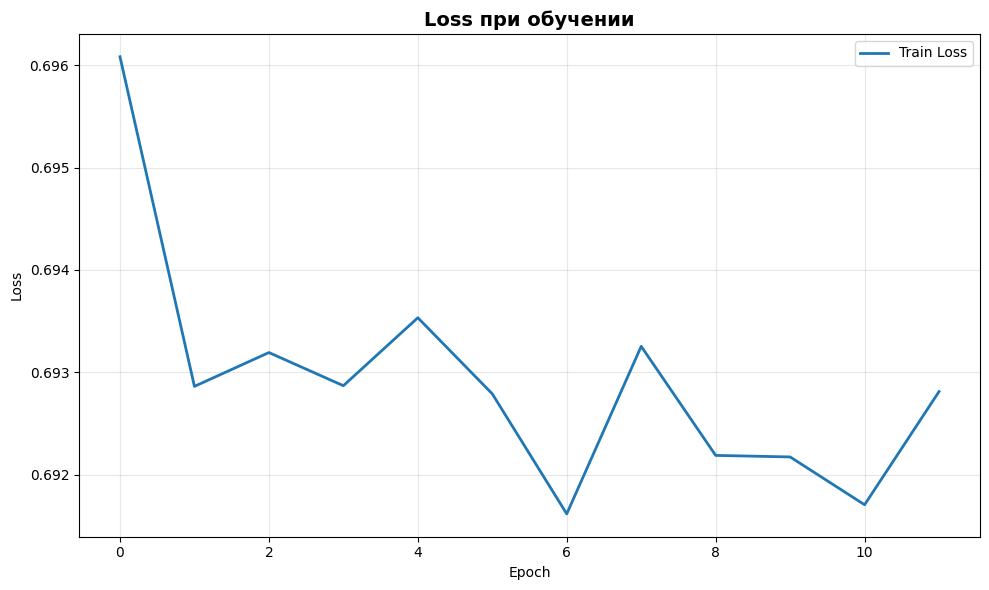

In [31]:
# ================================================================
# Визуализация процесса обучения
# ================================================================

plt.figure(figsize=(10, 6))

# График потерь (Loss)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.title('Loss при обучении', fontweight='bold', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
# ================================================================
# Прогноз на тестовой выборке
# ================================================================

y_pred = model.predict(x_test_seq, verbose=1, batch_size=BATCH_SIZE)

y_pred_classes = (y_pred > 0.5).astype("int32")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [33]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print(classification_report(y_test_seq, y_pred_classes))

              precision    recall  f1-score   support

           0       0.59      0.03      0.05       695
           1       0.49      0.98      0.65       650

    accuracy                           0.49      1345
   macro avg       0.54      0.50      0.35      1345
weighted avg       0.54      0.49      0.34      1345



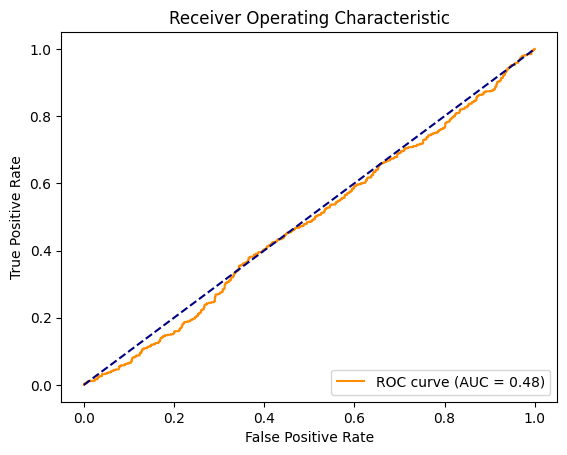

In [34]:
# ================================================================
# ROC-AUC
# ================================================================

# 1. FPR, TPR, thresholds
fpr, tpr, thresholds = roc_curve(y_test_seq, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Chance level
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## Расширяющиеся скользящие окна

In [36]:
rolling_test_df = pd.DataFrame()
model = None
scaler = None

for year in range(2021, 2027):
    print('Год:', year)
    
    # Разделение данных
    year_train = data[data['Date'].dt.year < year]
    year_test = data[data['Date'].dt.year == year]
    
    x_train = year_train.drop(columns=['Date', 'target']).to_numpy()
    x_test = year_test.drop(columns=['Date', 'target']).to_numpy()
    
    y_train = year_train['target'].to_numpy()
    y_test = year_test['target'].to_numpy()
    
    # Масштабирование
    if scaler is None:
        scaler = MinMaxScaler()
        x_train_scaled = scaler.fit_transform(x_train)
    else:
        x_train_scaled = scaler.transform(x_train).clip(-1, 1)
    
    x_test_scaled = scaler.transform(x_test).clip(-1, 1)
    
    # Создание последовательностей
    x_train_seq, y_train_seq = create_sequences(x_train_scaled, y_train, time_steps=TIME_STEPS)
    x_test_seq, y_test_seq = create_sequences(x_test_scaled, y_test, time_steps=TIME_STEPS)
    
    # Дообучение модели
    if model is None:
        # Первый год - создаем новую модель
        model, history = lstm_model(
            x_train=x_train_seq,
            y_train=y_train_seq,
            x_val=None,
            y_val=None,
            n_units=N_UNITS,
            num_layers=NUM_LSTM_LAYERS,
            learning_rate=LEARNING_RATE,
            batch_size=BATCH_SIZE,
            dropout=DROPOUT,
            epochs=EPOCHS,
            patience=5,
            loss='binary_crossentropy',
            verbose=1
        )
    else:
        model.compile(
            optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        history = model.fit(
            x_train_seq, y_train_seq,
            batch_size=BATCH_SIZE,
            epochs=EPOCHS // 2,
            verbose=1,
            callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
        )
    
    # Предсказания
    y_pred = model.predict(x_test_seq, verbose=1, batch_size=BATCH_SIZE)
    y_pred_classes = (y_pred > 0.5).astype("int32")
    
    # ВАЖНО: обрезаем year_test на такое же количество строк, сколько предсказаний
    year_test_aligned = year_test.iloc[TIME_STEPS:].copy()
    
    # Если длины не совпадают, обрезаем до минимальной
    min_len = min(len(y_pred_classes), len(year_test_aligned))
    
    if len(y_pred_classes) != len(year_test_aligned):
        print(f"Предупреждение: несоответствие длин. Обрезаю до {min_len}")
        y_pred_classes = y_pred_classes[:min_len]
        y_pred = y_pred[:min_len]
        year_test_aligned = year_test_aligned.iloc[:min_len]
    
    year_test_aligned['prediction'] = y_pred_classes
    year_test_aligned['prediction_prob'] = y_pred
    
    rolling_test_df = pd.concat([rolling_test_df, year_test_aligned], axis=0)

Год: 2021
Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5052 - loss: 0.6965
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5071 - loss: 0.6938
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5022 - loss: 0.6928
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5184 - loss: 0.6939
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4978 - loss: 0.6929
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5046 - loss: 0.6930
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5163 - loss: 0.6925
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5230 - loss: 0.6921
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4920 - loss: 0.6943
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5049 - loss: 0.6926
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5123 - loss: 0.6924
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s

In [37]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print(classification_report(rolling_test_df['target'], rolling_test_df['prediction']))

              precision    recall  f1-score   support

           0       0.50      0.52      0.51       635
           1       0.47      0.45      0.46       604

    accuracy                           0.48      1239
   macro avg       0.48      0.48      0.48      1239
weighted avg       0.48      0.48      0.48      1239

